# Kovasznay flow: nonlinear coupled Navier-Stokes


Kovasznay flow is a closed-form exact solution of the steady 2D incompressible Navier-Stokes equations:

$$
\mathbf u \cdot \nabla \mathbf u = -\nabla p + \frac{1}{Re}\nabla^2 \mathbf u,
\qquad \nabla \cdot \mathbf u = 0
$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes import tree
from archimedes.experimental.approximation import (
    ConcatBasis,
    ConstrainedBasis,
    FunctionSpace,
    LagrangeBasis,
    OrthogonalPolynomialBasis,
)
from archimedes.measure import LegendreMeasure, UnitInterval
from archimedes.quadrature import gauss_legendre


## Exact solution

$$
u(x,y) = 1 - e^{\lambda x}\cos(2\pi y), \qquad
v(x,y) = \frac{\lambda}{2\pi} e^{\lambda x}\sin(2\pi y), \qquad
p(x,y) = \frac12\left(1 - e^{2\lambda x}\right)
$$

$$
\lambda = \frac{Re}{2} - \sqrt{\frac{Re^2}{4} + 4\pi^2}
$$

The domain is $x \in [-0.5, 1.0]$ (bounded, the flow decays exponentially
away from a vortex near $x=0$), $y \in [-0.5, 1.5]$, at $Re=40$.


In [2]:
Re = 40.0
lam = Re / 2 - np.sqrt(Re**2 / 4 + 4 * np.pi**2)

A, B = -0.5, 1.0  # x domain (bounded)
C, D = -0.5, 1.5  # y domain (periodic, 2 periods)


def u_exact(x, y):
    return 1 - np.exp(lam * x) * np.cos(2 * np.pi * y)


def v_exact(x, y):
    return (lam / (2 * np.pi)) * np.exp(lam * x) * np.sin(2 * np.pi * y)


def p_exact(x, y):
    return 0.5 * (1 - np.exp(2 * lam * x))


## Design

Three deliberate choices, each following the real, validated approach used
by [shenfun](https://shenfun.readthedocs.io) (a production Chebyshev/Legendre-Fourier
spectral-Galerkin library) rather than improvised from scratch:

- **Weak (Galerkin) form, not strong form.** The viscous term is tested via
  $\int \nabla u \cdot \nabla v\,dx$ -- only *first* derivatives, of both
  trial and test function, anywhere in the assembly. No second-derivative
  operator is ever formed.
- **Velocity**: a composite "vertex + bubble" basis --
  `ConcatBasis((vertex, ConstrainedBasis.dirichlet(bubble)))` -- two cardinal
  endpoint functions carrying the (inhomogeneous) boundary values, plus
  homogeneous, exactly-Dirichlet-vanishing Legendre "bubble" modes for the
  interior. This is the SEM vertex/bubble construction already used
  elsewhere in this module, and it's exactly Shen's composite basis
  ($\phi_k = L_k - L_{k+2}$) by another route.
- **Pressure**: the plain orthogonal Legendre space (`FunctionSpace.legendre`),
  no boundary conditions -- correct, since pressure has none. Its nullspace
  (constant shift + one more mode, at the zero-wavenumber Fourier block) is
  removed by pinning two degrees of freedom directly, mirroring shenfun's own
  `Stokes.py` demo.

Velocity and pressure are two independent `FunctionSpace`s (not one shared
vector-valued `Function`), composed via a small `@struct` -- the same pattern
`beam.ipynb` validated for Timoshenko, generalized from two 1D fields to two
2D fields. State coefficients are kept in their natural 2D grid shape
(`(n_x, n_y)`) throughout, flattened only where a raw `@` against a basis
matrix needs it -- no manual index arithmetic anywhere.


In [3]:
@arc.struct
class KovasznayState:
    """Coefficients only, kept 2D-shaped (n_x, n_y) -- see beam.ipynb's
    design note on why not full Functions."""

    u: np.ndarray
    v: np.ndarray
    p: np.ndarray


def solve_kovasznay(n_bubble, n_p, n_y, Re):
    """Steady 2D Navier-Stokes (Kovasznay flow) via a weak-form, mixed
    velocity/pressure spectral-Galerkin discretization.

    Velocity: vertex + Legendre-bubble composite basis (x) x Fourier (y).
    Pressure: plain Legendre (x) x Fourier (y), two nullspace dofs pinned.
    """
    lam = Re / 2 - np.sqrt(Re**2 / 4 + 4 * np.pi**2)

    def u_ex(x, y):
        return 1 - np.exp(lam * x) * np.cos(2 * np.pi * y)

    def v_ex(x, y):
        return (lam / (2 * np.pi)) * np.exp(lam * x) * np.sin(2 * np.pi * y)

    def p_ex(x, y):
        return 0.5 * (1 - np.exp(2 * lam * x))

    vertex = LagrangeBasis(reference_nodes=np.array([-1.0, 1.0]))
    bubble = ConstrainedBasis.dirichlet(OrthogonalPolynomialBasis(LegendreMeasure(), n_bubble))
    vel_basis_x = ConcatBasis((vertex, bubble), quad_rule=gauss_legendre(n_bubble + 4))
    space_x_vel = FunctionSpace(vel_basis_x, UnitInterval.Parameters(a=A, b=B))
    space_x_p = FunctionSpace.legendre(n_p, a=A, b=B)
    space_y = FunctionSpace.fourier(n_y, a=C, b=D, kind="full")

    space_vel = FunctionSpace.tensor(space_x_vel, space_y)
    space_p = FunctionSpace.tensor(space_x_p, space_y)
    shape_vel, shape_p = space_vel.basis.shape, space_p.basis.shape
    n_vel, n_p_tot = space_vel.n_basis, space_p.n_basis

    left_x, right_x = space_x_vel.basis.boundary_dofs()

    # `space_vel.quad_rule` is the *reference*-domain rule; an explicit
    # override to `basis_matrix()` is used exactly as given, with no
    # auto-mapping -- map it onto the physical domain once, up front, and
    # share it everywhere u, v, and p need to be evaluated at the same nodes.
    shared_quad = space_vel.quad_rule.map_to(dims=[(A, B), (C, D)])

    Phi_vel = space_vel.basis_matrix(quad_rule=shared_quad)
    dPhi_vel_x = space_vel.basis_matrix(deriv=(1, 0), quad_rule=shared_quad)
    dPhi_vel_y = space_vel.basis_matrix(deriv=(0, 1), quad_rule=shared_quad)
    Phi_p = space_p.basis_matrix(quad_rule=shared_quad)

    u_exact_grid = space_vel.project(lambda pts: u_ex(pts[:, 0], pts[:, 1])).coefficients.reshape(shape_vel)
    v_exact_grid = space_vel.project(lambda pts: v_ex(pts[:, 0], pts[:, 1])).coefficients.reshape(shape_vel)
    p_exact_grid = space_p.project(lambda pts: p_ex(pts[:, 0], pts[:, 1])).coefficients.reshape(shape_p)

    def residual(state):
        u_flat = state.u.reshape((n_vel,))
        v_flat = state.v.reshape((n_vel,))
        p_flat = state.p.reshape((n_p_tot,))

        u_val, v_val = Phi_vel @ u_flat, Phi_vel @ v_flat
        u_x, u_y = dPhi_vel_x @ u_flat, dPhi_vel_y @ u_flat
        v_x, v_y = dPhi_vel_x @ v_flat, dPhi_vel_y @ v_flat
        p_val = Phi_p @ p_flat

        conv_x = u_val * u_x + v_val * u_y
        conv_y = u_val * v_x + v_val * v_y

        # Weak form: momentum tested against velocity basis (viscous term
        # integrated by parts once, pressure term integrated by parts once);
        # continuity tested directly (untransformed) against pressure basis.
        r_u = (
            Phi_vel.T @ conv_x
            - dPhi_vel_x.T @ p_val
            + (1.0 / Re) * (dPhi_vel_x.T @ u_x + dPhi_vel_y.T @ u_y)
        ).reshape(shape_vel)
        r_v = (
            Phi_vel.T @ conv_y
            - dPhi_vel_y.T @ p_val
            + (1.0 / Re) * (dPhi_vel_x.T @ v_x + dPhi_vel_y.T @ v_y)
        ).reshape(shape_vel)
        r_p = (Phi_p.T @ (u_x + v_y)).reshape(shape_p)

        # Essential BCs: each field's own boundary_dofs(), no global index.
        r_u[left_x, :] = state.u[left_x, :] - u_exact_grid[left_x, :]
        r_u[right_x, :] = state.u[right_x, :] - u_exact_grid[right_x, :]
        r_v[left_x, :] = state.v[left_x, :] - v_exact_grid[left_x, :]
        r_v[right_x, :] = state.v[right_x, :] - v_exact_grid[right_x, :]

        # Pressure nullspace at the zero-Fourier-wavenumber block: two
        # constraints needed (mean pressure + a second null direction),
        # matching shenfun's Stokes.py.
        r_p[0, 0] = state.p[0, 0] - p_exact_grid[0, 0]
        r_p[-1, 0] = state.p[-1, 0] - p_exact_grid[-1, 0]

        return tree.replace(state, u=r_u, v=r_v, p=r_p)

    state0 = KovasznayState(u=np.zeros(shape_vel), v=np.zeros(shape_vel), p=np.zeros(shape_p))
    sol = arc.optimize.root(residual, state0)  # plain default Newton -- no warm start needed
    return (
        space_vel.function(sol.u.reshape((n_vel,))),
        space_vel.function(sol.v.reshape((n_vel,))),
        space_p.function(sol.p.reshape((n_p_tot,))),
    )


## Verification

Spectral (exponential) convergence against the exact solution as the bubble
(and matching pressure) resolution increases, at fixed Fourier resolution.


In [4]:
x_check = np.linspace(A, B, 15)
y_check = np.linspace(C, D, 15)
XX, YY = np.meshgrid(x_check, y_check, indexing="ij")
pts_check = np.stack([XX.ravel(), YY.ravel()], axis=-1)


def check_error(u_fn, v_fn, p_fn):
    eu = np.max(np.abs(u_fn(pts_check) - u_exact(pts_check[:, 0], pts_check[:, 1])))
    ev = np.max(np.abs(v_fn(pts_check) - v_exact(pts_check[:, 0], pts_check[:, 1])))
    ep = np.max(np.abs(p_fn(pts_check) - p_exact(pts_check[:, 0], pts_check[:, 1])))
    return eu, ev, ep


print("max errors vs. exact solution:")
for n_bubble in [6, 8, 10, 12]:
    u_fn, v_fn, p_fn = solve_kovasznay(n_bubble, n_p=n_bubble, n_y=17, Re=Re)
    eu, ev, ep = check_error(u_fn, v_fn, p_fn)
    print(f"  n_bubble={n_bubble:2d}  err_u={eu:.3e}  err_v={ev:.3e}  err_p={ep:.3e}")


max errors vs. exact solution:


  n_bubble= 6  err_u=5.396e-05  err_v=2.818e-05  err_p=4.613e-04


  n_bubble= 8  err_u=1.344e-07  err_v=1.046e-07  err_p=3.972e-06


  n_bubble=10  err_u=1.962e-10  err_v=8.856e-11  err_p=2.331e-08


  n_bubble=12  err_u=2.476e-13  err_v=1.113e-13  err_p=9.577e-11


## Solution

The Kovasznay vortex: a jet issuing into a periodic array of counter-rotating
cells, decaying downstream.


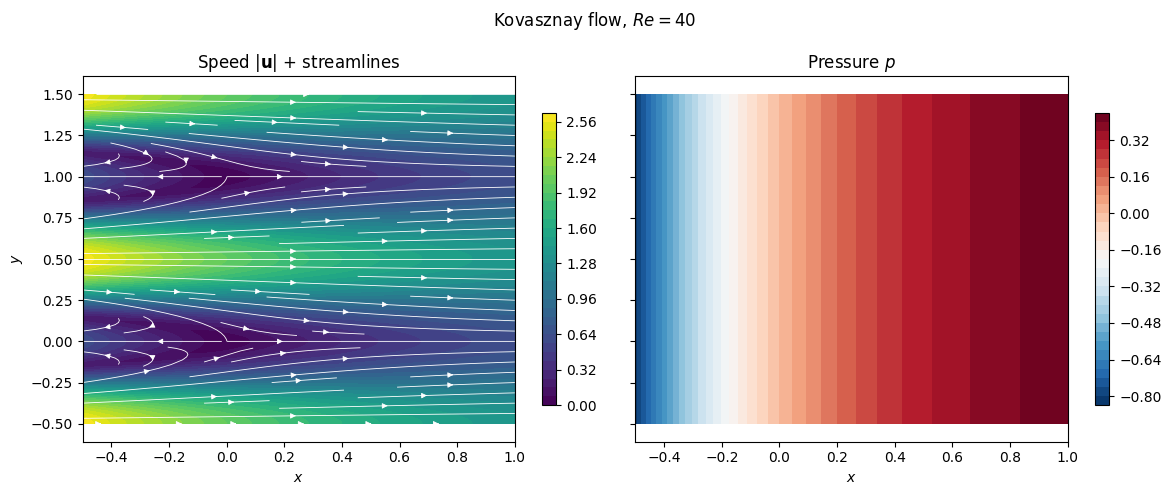

In [5]:
u_fn, v_fn, p_fn = solve_kovasznay(n_bubble=10, n_p=10, n_y=17, Re=Re)

x_plot = np.linspace(A, B, 120)
y_plot = np.linspace(C, D, 160)
XP, YP = np.meshgrid(x_plot, y_plot, indexing="ij")
pts_plot = np.stack([XP.ravel(), YP.ravel()], axis=-1)

U = u_fn(pts_plot).reshape(XP.shape)
V = v_fn(pts_plot).reshape(XP.shape)
P = p_fn(pts_plot).reshape(XP.shape)
speed = np.sqrt(U**2 + V**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

c0 = axes[0].contourf(XP, YP, speed, levels=40, cmap="viridis")
skip = (slice(None, None, 6), slice(None, None, 8))
axes[0].streamplot(
    x_plot, y_plot, U.T, V.T, color="white", linewidth=0.6, density=1.1, arrowsize=0.8
)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_title("Speed $|\\mathbf{u}|$ + streamlines")
fig.colorbar(c0, ax=axes[0], shrink=0.8)

c1 = axes[1].contourf(XP, YP, P, levels=40, cmap="RdBu_r")
axes[1].set_xlabel("$x$")
axes[1].set_title("Pressure $p$")
fig.colorbar(c1, ax=axes[1], shrink=0.8)

fig.suptitle(f"Kovasznay flow, $Re={Re:.0f}$")
plt.tight_layout()
plt.show()
